# Машинное обучение, ШАД
## Домашнее задание 6


**Правила:**

* Дедлайн **17 ноября 23:59**. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Для сдачи задания нужно загрузить **ноутбук в формате `ipynb`** в ЛМС.
* Выполнять задание необходимо полностью самостоятельно.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде этого Jupyter Notebook-а в оригинальном формате и сконвертированном в `pdf`.
* Для записи формул необходимо использовать $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.
* Решения не проверяются, если какое-то требование не выполнено.

**Баллы за задание:**

* Задача 1 &mdash; 1 балл
* Задача 2 &mdash; 2 балл
* Задача 3 &mdash; 2 балл
* Задача 4 &mdash; 2 балл
* Задача 5 &mdash; 3 балла


In [21]:
import numpy as np
import pandas as pd
import numba
import matplotlib.pyplot as plt
from IPython.display import Math

plt.rcParams.update({'text.usetex' : True, 'font.size' : 12})

np.random.seed(0)

---
### Задача 1. 

Ученые придумали новый тест для определения одной очень известной болезни, который показывает поразительные свойства:
* Вероятность того, что тест покажет положительный результат, если человек и правда болен, составляет 99%;
* Вероятность того, что тест покажет положительный результат, если человек на самом деле не болен, составляет 3%.

Посчитайте вероятность того, что человек реально болен, если тест показал положительный результат, с помощью формулы Байеса. Также известно, что в среднем на 100 случайных человек приходится двое болеющих.

### Решение

Даны априорные вероятности того, что человек болен ($H_1$) и что человек здоров ($H_2$), $H_1\sqcup H_2 = \Omega $:

$\mathbb{P}(H_1) = 0.02;\quad \mathbb{P}(H_2) = 0.98$.

Вероятность того, что тест покажет положительный результат, если человек и правда болен, составляет 0.99, то есть:

$\mathbb{P}(P | H_1) = 0.99$

Вероятность того, что тест покажет положительный результат, если человек на самом деле не болен, составляет 0.03:

$\mathbb{P}(P | H_2) = 0.03$

Найдем вероятность того, что человек реально болен при положительном результате теста, $\mathbb{P}(H_1|P)$, воспользовавшись формулой Байеса:

$\mathbb{P}(H_1|P) = \dfrac{\mathbb{P}(P | H_1) \mathbb{P}(H_1)}{\mathbb{P}(P)} = \dfrac{\mathbb{P}(P | H_1) \mathbb{P}(H_1)}{\mathbb{P}(P | H_1) \mathbb{P}(H_1) + \mathbb{P}(P | H_2) \mathbb{P}(H_2)} = \dfrac{0.99 \cdot 0.02}{0.99 \cdot 0.02 + 0.03 \cdot 0.98} = \dfrac{33}{82}\approx 0.4024$



---
### Задача 2. 

Рассмотрим два случая.

**a).** Пусть $X_1, \dots, X_n$ &mdash; выборка из распределения $\mathcal{N}(\theta, 1)$. 

**b).** Пусть $X_1, \dots, X_n$ &mdash; выборка из распределения $\mathcal{N}(0, \theta^{-1})$. 

В каждом случае подберите сопряженное семейство распределений и найдите соответствующее апостериорное распределение параметра $\theta$, а также его математическое ожидание.

Подумайте, какое распределение является сопряженным в случае если неизвестны оба параметра нормального распределения.


### Решение

**a)**  $X_1, \dots, X_n \sim \text{ iid } \mathcal{N}(\theta, 1)$

$X|\theta$ имеет следующую плотность распределения:

$ p(X = x| \theta = t) = 
\prod\limits_{i=1}^n \dfrac{1}{\sqrt{2\pi}} \exp\left[-\dfrac{1}{2}(x_i-t)^2\right] = 
(2\pi)^{-n/2} \exp\left[-\dfrac{1}{2}\sum\limits_{i=1}^{n}(x_i-t)^2\right] = 
(2\pi)^{-n/2} \exp\left[-\dfrac{1}{2}\left(\sum\limits_{i=1}^{n}(x_i-\overline{x})^2 + n(\overline{x} - t)^2\right)\right],
$

где $\overline{x}$ &mdash; выборочное среднее.

Выберем в качестве априорного нормальное распределение $\mathcal{N}(\mu_0, 1/\tau_0)$, имеющее плотность:

$p(\theta = t) = \sqrt{\dfrac{\tau_0}{2\pi}} \exp\left(-\dfrac{1}{2}\tau_0(t-\mu_0)^2\right)$.

Апостериорное распределение $\theta | X$ в этом случае имеет плотность:

$\begin{aligned}
p(\theta = t | X = x) &\propto p(X = x| \theta = t) \cdot p(\theta = t) \\
&=(2\pi)^{-n/2} \exp\left[-\dfrac{1}{2}\sum\limits_{i=1}^{n}(x-t)^2\right] \sqrt{\dfrac{\tau_0}{2\pi}} \exp\left[-\dfrac{1}{2}\tau_0(t-\mu_0)^2\right] \\
&\propto \exp\left[ -\dfrac{1}{2}\left(\sum\limits_{i=1}^{n}(x_i-\overline{x})^2 + n(\overline{x} - t)^2\right) -\dfrac{1}{2}\tau_0(t-\mu_0)^2 \right] \\
&\propto \exp\left[ -\dfrac{1}{2}\left(n(\overline{x} - t)^2 + \tau_0(t-\mu_0)^2\right) \right] \\
&=\exp\left[ -\dfrac{1}{2} (n+\tau_0) \left( t - \dfrac{n\overline{x} + \tau_0 \mu_0}{n+\tau_0} \right)^2 + \dfrac{n\tau_0}{n+\tau_0}(\overline{x}-\mu_0)^2 \right] \\
& \propto \exp\left[ -\dfrac{1}{2} (n+\tau_0) \left( t - \dfrac{n\overline{x} + \tau_0 \mu_0}{n+\tau_0} \right)^2\right].
\end{aligned}$

В полученной апостериорной плотности $q(t|x)$ можно узнать нормальное распределение. Таким образом, апостериорное распределение среднего при фиксированной единичной дисперсии нормального распределения имеет вид:

$\theta | X \sim \mathcal{N}\left(\dfrac{n\overline{x} + \tau_0 \mu_0}{n+\tau_0},\;  \dfrac{1}{n+\tau_0} \right).$

Из распределения $\theta | X$ сразу можно выписать математческое ожидание:

$\mathbb{E}\left[\theta | X\right] = \dfrac{n\overline{x} + \tau_0 \mu_0}{n+\tau_0}$.

**b)** $X_1, \dots, X_n \sim \text{ iid } \mathcal{N}(0, \theta^{-1})$

$X|\theta$ имеет следующую плотность распределения:

$p(X = x| \theta = t) = 
\prod\limits_{i=1}^n \sqrt{\dfrac{t}{2\pi}} \exp\left[-\dfrac{1}{2}t x_i^2\right] = 
\left(\dfrac{t}{2\pi}\right)^{n/2} \exp\left[-\dfrac{1}{2}t\sum\limits_{i=1}^{n} x_i^2\right] \propto 
t^{n/2} \exp\left[-\dfrac{1}{2}t\sum\limits_{i=1}^{n} x_i^2\right]$

Выберем в качестве априорного гамма-распределение $\Gamma({\alpha_0},{\beta_0})$, имеющее плотность:

$p(\theta = t) = \dfrac{{\beta_0}^{\alpha_0}}{\Gamma({\alpha_0})}t^{{\alpha_0}-1}\exp(-{\beta_0} t) \propto t^{{\alpha_0}-1}\exp(-{\beta_0} t)$.

Апостериорное распределение $\theta | X$ в этом случае имеет плотность:

$\begin{aligned}
p(\theta = t | X = x)&\propto p(X = x | \theta = t) \cdot p(\theta = t) \\
&= \left(\dfrac{t}{2\pi}\right)^{n/2} \exp\left[-\dfrac{1}{2}t\sum\limits_{i=1}^{n} x_i^2\right] \dfrac{{\beta_0}^{\alpha_0}}{\Gamma({\alpha_0})}t^{{\alpha_0}-1}\exp(-{\beta_0} t) \\
&\propto t^{n/2} \exp\left[-\dfrac{1}{2}t\sum\limits_{i=1}^{n} x_i^2\right] t^{{\alpha_0}-1}\exp(-{\beta_0} t) \\
&= t^{{\alpha_0} +n/2 -1} \exp\left[-\left({\beta_0} + \dfrac{1}{2}\sum\limits_{i=1}^{n} x_i^2\right)t\right].
\end{aligned}$

В полученной апостериорной плотности $q(t|x)$ можно узнать гамма распределение. Таким образом, апостериорное распределение точности (обратной дисперсии) при фиксированном нулевом среднем нормального распределения имеет вид:

$\theta | X \sim \text{Gamma}\left({\alpha_0} +n/2,\;  {\beta_0} + \dfrac{1}{2}\sum\limits_{i=1}^{n} x_i^2 \right).$

Из распределения $\theta | X$ сразу можно выписать математческое ожидание:

$\mathbb{E}\left[\theta | X\right] = \dfrac{{\alpha_0} +n/2}{{\beta_0} + \dfrac{1}{2}\sum\limits_{i=1}^{n} x_i^2}$.

**c)** $X_1, \dots, X_n \sim \text{ iid } \mathcal{N}(\mu, \tau^{-1})$

Аналогично пунктам (a) и (b), $X|\mu, \tau$ имеет плотность распределения:

$ p(X=x|\mu=z,\tau=t) = 
\prod\limits_{i=1}^n \sqrt{\dfrac{t}{2\pi}} \exp\left[-\dfrac{1}{2}t(x_i-z)^2\right] = 
\left(\dfrac{t}{2\pi}\right)^{n/2} \exp\left[-\dfrac{1}{2}t\sum\limits_{i=1}^{n}(x_i-z)^2\right] \propto
t^{n/2} \exp\left[-\dfrac{1}{2}t\left(\sum\limits_{i=1}^{n}(x_i-\overline{x})^2 + n(\overline{x} - z)^2\right)\right].
$

Сопряженное распределение не будет являться простым произведением плотностей, полученных в (a) и (b), так как среднее $\mu$ и точность $\tau$ **не** являются независимыми. Например, сумма квадратов отклонений зависит от среднего, а дисперсия среднего, очевидно, зависит от диспрерсии случайной величины. 

Поэтому рассмотрим два распределения, $\mu | \tau$ и $\tau$, используем их произведение в качестве сопряженного:

$
\mu | \tau \sim \mathcal{N}(\mu_0, n_0 \tau);\quad \tau \sim \text{Gamma}(\alpha_0,\beta_0)
$

Рассмотрим для начала $\mu | X, \tau$. Воспользуемся результатом пункта (a), но с учетом произвольной, не обязательно единичной, точности $\tau$ (обратной дисперсии), выводится абсолютно аналогично:

$\mu | X, \tau \sim \mathcal{N}\left(\dfrac{n \tau \overline{x} + n_0\tau \mu_0}{n\tau+n_0\tau},\;  \dfrac{1}{n\tau+n_0\tau} \right)$

Теперь рассмортим $\tau | X$. Для получения плотности этого распределения возьмем совместную плотность $\mu, \tau | X$ и найдем маргинальное распределение по $\tau$, проинтегрировав по $\mu$:

$\begin{aligned}
p(\mu=z, \tau = t | X = x) &\propto p(X=x|\mu=z, \tau = t) \cdot p(\mu = z | \tau=t) \cdot p(\tau = t)\\
&\propto t^{n/2} \exp\left[ -\frac{1}{2} t \sum\limits_{i=1}^n (x_i - \mu)^2 \right] \cdot t^{1/2} \exp\left[ -\frac{1}{2} n_0 t \sum\limits_{i=1}^n (z - \mu_0)^2 \right] \cdot 
t^{\alpha_0 - 1} \exp(-\beta_0 t)\\
&\propto t^{\alpha_0 + n/2 - 1} \exp\left[ -t \left( \beta_0 + \frac{1}{2}\sum_{i=1}^n (x_i - \overline{x})^2 \right) \right] t^{1/2} \exp\left[ \frac{1}{2}t\left( n_0(z - \mu_0)^2 + n (\overline{x} - z)^2 \right) \right].
\end{aligned}$

Взяв интеграл по $z$, получаем нормировочный коэффициент: $t^{-1/2} \exp\left[ \dfrac{nn_0 t (\overline{x}-\mu_0)^2}{2(n + n_0)} \right]$. Таким образом, плотность распределения $\tau|X$ имеет вид:

$\begin{aligned}
p(\tau=t | X=x) \propto 
t^{\alpha_0 + n/2 - 1} \exp\left[ -t \left( \beta_0 + \dfrac{1}{2}\sum\limits_{i=1}^n (x_i - \overline{x})^2 + \dfrac{nn_0 (\overline{x}-\mu_0)^2}{2(n + n_0)} \right) \right], 
\end{aligned}$

то есть это апостериорным распределением для $\tau$ является гамма-распределение. 

Подытожим:

Для случайной величины $X|\mu, \tau \sim \text{ iid } \mathcal{N}(\mu, \tau^{-1})$ c априорным распределением $\mu | \tau \sim \mathcal{N}(\mu_0, n_0\tau)$ и $\tau \sim \text{Gamma}(\alpha_0,\beta_0)$ апостериорным распределением является $\mu, \tau | X$, факторизуемое в две случайные величины $\mu | X, \tau$ и $\tau | X$:

$
\mu | X, \tau \sim \mathcal{N}\left(\dfrac{n \tau \overline{x} + n_0\tau \mu_0}{n\tau+n_0\tau},\;  \dfrac{1}{n\tau+n_0\tau} \right);\quad 
\tau | X \sim \text{Gamma}\left({\alpha_0} +n/2,\;  {\beta_0} + \dfrac{1}{2}\sum\limits_{i=1}^{n} (x_i - \overline{x})^2 + \dfrac{nn_0 (\overline{x}-\mu_0)^2}{2(n + n_0)} \right),
$


Апостериорное распределение $\mu, \tau | X$ также называют нормальное-гамма распределение.


---
### Задача 3.

Рассмотрим столбец Alcalinity of ash датасета <a href="http://archive.ics.uci.edu/ml/datasets/Wine">о вине</a>. Цель &mdash; оценить среднего значения этого признака. 

Для простоты дальнейших вычислений выберите некоторым образом дисперсию данных и считайте ее известной. На практике это не так, и дисперсию можно и нужно оценивать, но мы не хотим сильно усложнять учебную задачу.

In [1]:
<...>

SyntaxError: invalid syntax (3000440494.py, line 1)

Из класса сопряженных распределений выберите априорное распределение для среднего значения на основе своих представлений, не используя данные. Подсказка: загляните в семинар.

In [ ]:
<...>

Визуализируйте динамику изменения апостериорного распределения, последовательно добавляя к данным по 20 объектов. Примеры кода можно посмотреть в семинаре.

In [ ]:
<...>

**Вывод:**

<...>

---
### Задача 4.

Некоторая ML-модель имеет один параметр $\theta$, который обучается посредством *минимизации* функции
$$\mathcal{L}(\theta) = \mathsf{E} \exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right),$$
где $\xi$ имеет стандартное нормальное распределение, а $\eta$ &mdash; пуассоновское распределение с параметром 5 и не зависит от $\eta$.


Оптимизируйте эту функцию, используя стохастический градиентный спуск. Необходимо записать формулу шага и реализовать процедуру оптимизации.

<details>
  <summary>Подсказка</summary>

Посчитайте производную этой функции по $\theta$, поменяв местами интеграл (мат. ожидание) и производную. Далее оцените мат. ожидание по методу Монте-Карло.

</details>

Распишем по определению математическое ожидание:

$\begin{aligned}
\mathcal{L}(\theta) = \mathbb{E}_{\xi,\eta} \left[\exp\left(-\dfrac{\xi^2\sqrt{\eta}}{1+\theta^2}\right)\right] = 
\sum\limits_{k\in\mathbb{N}_0} \int\limits_{\mathbb{R}} \exp\left(-\frac{x^2\sqrt{k}}{1+\theta^2}\right) p_\xi(x) p_\eta(k)\; dx
\end{aligned}$,

где $p_\xi(x) = \dfrac{1}{\sqrt{2\pi}} \exp\left(-\dfrac{x^2}{2}\right), \;p_\eta(k) = \dfrac{5^k}{k!}e^{-5}$ &mdash; плотности стандартного нормального распределения и пуассоновского с параметром 5, соответственно.

Найдем градиент функции по параметру $\theta$:

$\begin{aligned}
\nabla_\theta \mathcal{L}(\theta) =
\mathbb{E}_{\xi,\eta} \left[ \nabla_\theta\exp\left(-\dfrac{\xi^2\sqrt{\eta}}{1+\theta^2}\right)\right] =
\sum\limits_{k\in\mathbb{N}_0} \int\limits_{\mathbb{R}} \nabla_\theta \exp\left(-\frac{x^2\sqrt{k}}{1+\theta^2}\right) p_\xi(x) p_\eta(k)\; dx
\end{aligned}$.

Найдем производную функции под математическим ожиданием (распределения не зависят от параметра $\theta$):

$\begin{aligned}
\nabla_\theta \exp\left(-\frac{x^2\sqrt{k}}{1+\theta^2}\right) =
\frac{2\theta x^2\sqrt{k}}{(1+\theta^2)^2} \exp\left(-\frac{x^2\sqrt{k}}{1+\theta^2}\right)
\end{aligned}$.

Таким образом, получем градиент $\nabla_\theta \mathcal{L}(\theta)$, который выражается через матожидание от функции случайных величин $\xi$ и $\theta$, имеющих известное распределение:

$\begin{aligned}
\nabla_\theta \mathcal{L}(\theta) = \mathbb{E}_{\xi,\eta} \left[ \frac{2\theta \xi^2\sqrt{\eta}}{(1+\theta^2)^2} \exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right) \right]
\end{aligned}$.

Будем оптимизировать функцию при помощи градиентного спуска, оценивая на каждой итерации матожидание градиента методом Монте-Карло. Найдем точку минимума $\theta^*$:

In [12]:
@numba.njit(parallel=True)
def gen_xi(samples: int = 1) -> np.ndarray:
    return np.random.randn(samples)

@numba.njit(parallel=True)
def gen_eta(samples: int = 1) -> np.ndarray:
    return np.random.poisson(lam=5, size=(samples, ))

@numba.njit(parallel=True)
def calc_loss(theta: float, xi: np.ndarray[float], eta: np.ndarray[int]) -> np.ndarray[float]:
    return np.exp(-xi**2 * np.sqrt(eta) / (1 + theta**2))

@numba.njit(parallel=True)
def calc_grad_loss(theta: float, xi: np.ndarray[float], eta: np.ndarray[int]) -> np.ndarray[float]:
    a = xi**2 * np.sqrt(eta)
    return (2 * theta * a) / (1 + theta**2)**2 * np.exp(-a / (1 + theta**2))

@numba.njit(parallel=True)
def monte_carlo_opt(
        init_theta: float, 
        lr: float,
        samples_per_step: int,
        max_iter: int
    ) -> tuple[float, list[float], list[float], list[float]]:
    theta = init_theta
    
    grad_logs = []
    loss_logs = []
    theta_logs = []
    
    for _ in range(max_iter):
        xi = gen_xi(samples_per_step)
        eta = gen_eta(samples_per_step)
        
        grad = np.mean(calc_grad_loss(theta, xi, eta))
        theta -= lr * grad
        
        loss = np.mean(calc_loss(theta, xi, eta))
        
        grad_logs.append(grad)
        loss_logs.append(loss)
        theta_logs.append(theta)
        
    return theta, grad_logs, loss_logs, theta_logs

In [16]:
max_iter = 10000
samples_per_step = 10000
lr = 1.
init_theta = 13.


theta_star, *logs = monte_carlo_opt(init_theta, lr, samples_per_step, max_iter)

In [18]:
np.mean(calc_loss(theta_star, gen_xi(10**7), gen_eta(10**7)))

0.44157642333846625

In [19]:
opt_loss = np.mean(calc_loss(theta_star, gen_xi(10**7), gen_eta(10**7)))
display(Math(fr'$\theta^* = {theta_star:.9f}$'),Math(fr'$L(\theta^*) = {opt_loss:.9f}$'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

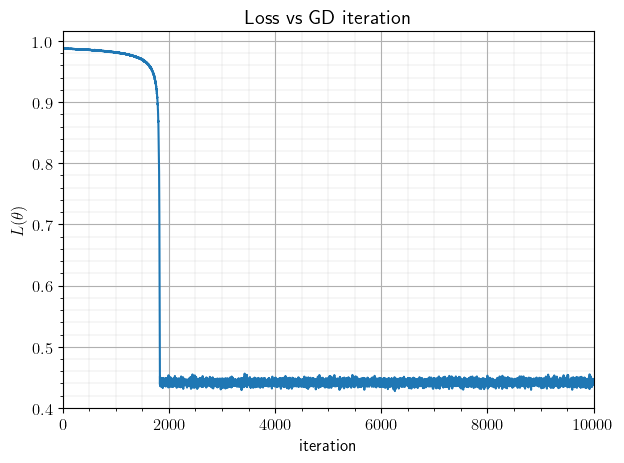

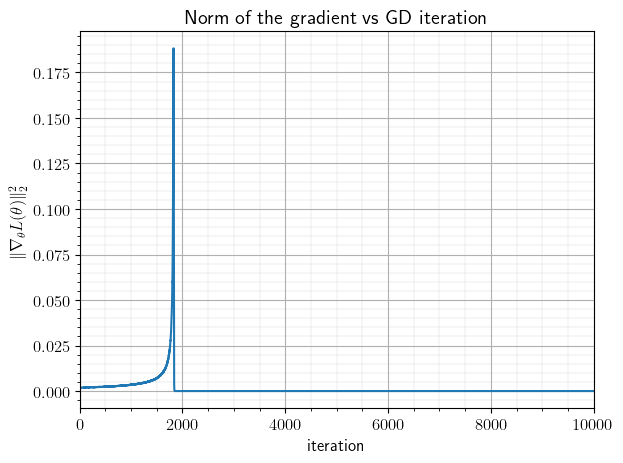

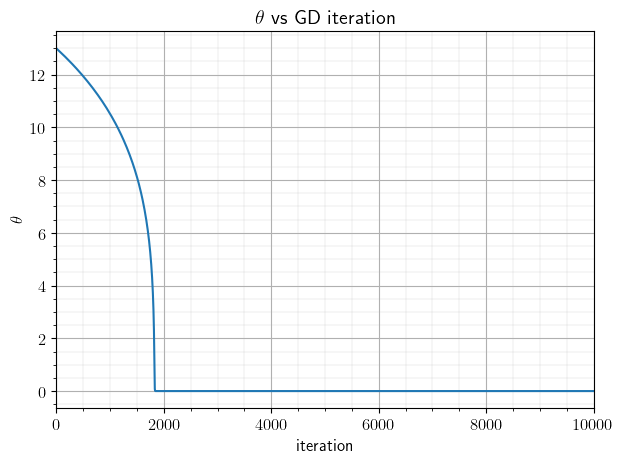

In [20]:
grad_logs, loss_logs, theta_logs = logs


plt.figure()
plt.title("Loss vs GD iteration")
plt.plot(loss_logs)
plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5); plt.minorticks_on()
plt.xlabel("iteration"); plt.ylabel(fr"$L(\theta)$")
plt.xlim([0, max_iter])
plt.tight_layout()

plt.figure()
plt.title("Norm of the gradient vs GD iteration")
plt.plot(grad_logs)
plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5); plt.minorticks_on()
plt.xlabel("iteration"); plt.ylabel(fr"$\Vert \nabla_\theta L(\theta) \Vert_2^2$")
plt.xlim([0, max_iter])
plt.tight_layout()

plt.figure()
plt.title(r"$\theta$ vs GD iteration")
plt.plot(theta_logs)
plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5); plt.minorticks_on()
plt.xlabel("iteration"); plt.ylabel(fr"$\theta$")
plt.xlim([0, max_iter])
plt.tight_layout()

---
### Задача 5.

> *Не забывайте примеры кода смотреть в семинарских ноутбуках.*

Загрузите данные `flats_moscow.txt` о стоимости квартир в Москве

In [ ]:
data = pd.read_csv('./flats_moscow.txt', sep='\t', index_col=0)
data.head()

Постройте график зависимости цены квартиры (price) от ее общей площади (totsp). Что можно сказать о данных?

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(data['totsp'], data['price'], alpha=0.3)
plt.xlabel('Общая площадь квартиры')
plt.ylabel('Цена квартиры');

Постройте с помощью PyMC линейную регрессию для предсказания цены квартиры (price) от ее общей площади (totsp). Используйте следующие распределения:
* Априорное распределение на коэффициенты &mdash; нормальное с нулевым средним и среднеквадратичным разбросом 20;
* Ошибка имеет нормальное распределение с нулевым средним;
* Априорное распределение на дисперсию ошибки &mdash; модуль распределения Коши.

Запишите модель формулами:

<...>

Реализуйте эту модель и проведите 3000 итераций семплирования

In [ ]:
with pm.Model() as model:
    <...>

Постройте `pm.plot_trace`. Что можно по нему сказать? Какое апострериорное распределение имеют параметры модели?

In [ ]:
<...>

Теперь вам нужно построить предсказательный интервал (ленту) для каждого $x$ по сетке значений totsp, взяв область, в которую попадает 95% вероятностной массы апостериорного распределения. Иначе говоря, на основе построенной модели нужно для каждой площади квартиры $x$ вычислить 95%-й диаппазон цен на квартиры с такой мощностью.

Для выполнения этого пункта задайте сетку значений площади квартиры и с помощью `pm.sample_posterior_predictive` проведите 10000 итераций семплирования из предиктивного распределения.

In [ ]:
<...>

Проверьте размерность полученной матрицы чисел, она должна быть равна $(10000, N)$, где $N$ &mdash; количество значений $x$ в выбранной вами сетке. Тем самым для каждого значения $x$ у вас есть 10000 независимых реализаций цены квартиры с такой площадью. Далее по этим реализациям вы можете посчитать все интересующие вас характеристики.

*Замечание.* На самом деле полученные значения строго не являются независимыми, но мы не будем обращать на это внимание. Если вам будет интересно, можно подробнее почитать про методы MCMC.

In [ ]:
<...>

На основе полученных семплов постройте график предсказательного интервала (ленты). Для этого можно взять квантили у семплов для каждого $x$.

In [ ]:
<...>

Что вы можете сказать по этому графику?

Предложите способ, как исправить модель. Реализуйте эту модель, постройте для нее график предсказательного интервала.

In [ ]:
<...>

Теперь проведем небольшую аналитику. Допустим, мы хотим купить квартиру площадью 75 квадратных метров. Простройте график плотности предсказательного распределения цены такой квартиры. Посчитайте также вероятность того, что квартира площадью 75 квадратных метров имеет цену не более 100.

In [ ]:
<...>

Насколько вообще изменяется цена квартиры при увеличении ее площади на 1 метр? Постройте для этого апостериорное распределение этого параметра, а также посчитайте среднее значение и 95%-й интервал

In [ ]:
<...>